In [1]:
# Cell 1 - Imports
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import models, transforms
from pathlib import Path
from PIL import Image
import json
import os
import sys

# Add model folder to path
sys.path.append(str(Path("..").resolve() / "model"))

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

✅ Using device: cuda


In [2]:
# Cell 2 - Load model and class names
BASE_DIR = Path("..").resolve()

# Load class names
with open(BASE_DIR / "utils" / "dataset_info.json", "r") as f:
    dataset_info = json.load(f)

NUM_CLASSES = dataset_info["num_classes"]
CLASS_NAMES = dataset_info["class_names"]

# Build model
class SkinDiseaseModel(nn.Module):
    def __init__(self, num_classes):
        super(SkinDiseaseModel, self).__init__()
        self.backbone = models.efficientnet_b0(weights='DEFAULT')
        for param in list(self.backbone.parameters())[:-20]:
            param.requires_grad = False
        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()
        self.disease_head = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
        self.severity_head = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 3)
        )
    def forward(self, x):
        features     = self.backbone(x)
        disease_out  = self.disease_head(features)
        severity_out = self.severity_head(features)
        return disease_out, severity_out

# Load trained weights
model = SkinDiseaseModel(num_classes=NUM_CLASSES).to(device)
model.load_state_dict(
    torch.load(BASE_DIR / "checkpoints" / "best_model.pth",
               map_location=device)
)
model.eval()

print(f"✅ Model loaded successfully!")
print(f"✅ Classes: {NUM_CLASSES}")
print(f"✅ Class names: {CLASS_NAMES}")

C:\Users\shruti\AppData\Local\Temp\ipykernel_19944\2274479900.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(BASE_DIR / "checkpoints" / "best_model.pth",


✅ Model loaded successfully!
✅ Classes: 20
✅ Class names: ['cat_flea_allergy', 'cat_healthy', 'cat_ringworm', 'cat_scabies', 'dog_demodicosis', 'dog_dermatitis', 'dog_fungal_infections', 'dog_healthy', 'dog_hypersensitivity', 'dog_ringworm', 'human_atopic_dermatitis', 'human_basal_cell_carcinoma', 'human_benign_keratosis', 'human_eczema', 'human_melanocytic_nevi', 'human_melanoma', 'human_psoriasis', 'human_seborrheic_keratoses', 'human_tinea_ringworm', 'human_warts_molluscum']


In [3]:
# Cell 3 - Image preprocessing function
def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    # Load image
    image = Image.open(image_path).convert("RGB")
    
    # Apply transforms
    image_tensor = transform(image).unsqueeze(0)
    
    return image, image_tensor

print("✅ Preprocessing function defined!")

✅ Preprocessing function defined!


In [4]:
# Cell 4 - Severity adjustment based on patient data
SEVERITY_LABELS = ["Mild", "Moderate", "Severe"]

def adjust_severity(severity_idx, patient_data):
    age      = patient_data.get("age", 25)
    duration = patient_data.get("duration", "Less than 1 week")
    spreading = patient_data.get("spreading", False)
    itchy    = patient_data.get("itchy", False)
    species  = patient_data.get("species", "Human")
    
    # Bump up severity for high risk cases
    if species == "Human":
        if age > 60 or age < 5:
            severity_idx = min(severity_idx + 1, 2)
    
    if "More than 1 month" in duration:
        severity_idx = min(severity_idx + 1, 2)
    elif "2-4 weeks" in duration:
        severity_idx = min(severity_idx + 1, 2)
    
    if spreading:
        severity_idx = min(severity_idx + 1, 2)
    
    if itchy and severity_idx == 0:
        severity_idx = 1
    
    return severity_idx

print("✅ Severity adjustment function defined!")

✅ Severity adjustment function defined!


In [5]:
# Cell 5 - Main prediction function
DISEASE_INFO = {
    "eczema": {
        "symptoms": ["Dry skin", "Intense itching", "Red patches", "Inflammation"],
        "mild":     "Moisturize regularly. Use fragrance-free soap.",
        "moderate": "Apply prescribed topical steroids. Avoid triggers.",
        "severe":   "🚨 Consult a dermatologist immediately."
    },
    "melanoma": {
        "symptoms": ["Irregular dark mole", "Color changes", "Bleeding spot"],
        "mild":     "Monitor closely. Take photo weekly.",
        "moderate": "⚠️ See a dermatologist within a week.",
        "severe":   "🚨 URGENT - See oncologist immediately."
    },
    "atopic_dermatitis": {
        "symptoms": ["Dry skin", "Itching", "Red patches", "Scaly skin"],
        "mild":     "Keep skin moisturized. Avoid hot showers.",
        "moderate": "See dermatologist for topical treatment.",
        "severe":   "🚨 Immediate dermatologist consultation needed."
    },
    "basal_cell_carcinoma": {
        "symptoms": ["Pearly bump", "Flat flesh colored lesion", "Bleeding sore"],
        "mild":     "See dermatologist for evaluation.",
        "moderate": "Urgent dermatologist appointment required.",
        "severe":   "🚨 Immediate medical consultation required."
    },
    "melanocytic_nevi": {
        "symptoms": ["Brown mole", "Round shape", "Smooth border"],
        "mild":     "Monitor for changes. Apply sunscreen.",
        "moderate": "See dermatologist for evaluation.",
        "severe":   "🚨 Urgent dermatologist visit required."
    },
    "benign_keratosis": {
        "symptoms": ["Waxy growth", "Stuck on appearance", "Brown color"],
        "mild":     "Keep area moisturized. Avoid picking.",
        "moderate": "Consult dermatologist for treatment.",
        "severe":   "🚨 See dermatologist immediately."
    },
    "psoriasis": {
        "symptoms": ["Red patches", "Silvery scales", "Dry skin", "Itching"],
        "mild":     "Keep skin moisturized. Gentle sunlight may help.",
        "moderate": "Consult doctor for topical treatments.",
        "severe":   "🚨 Biological therapy may be needed."
    },
    "seborrheic_keratoses": {
        "symptoms": ["Waxy brown growth", "Stuck on look", "Itching"],
        "mild":     "No treatment needed if asymptomatic.",
        "moderate": "See dermatologist if irritated.",
        "severe":   "🚨 Consult dermatologist immediately."
    },
    "tinea_ringworm": {
        "symptoms": ["Ring shaped rash", "Scaly skin", "Itching", "Hair loss"],
        "mild":     "Apply antifungal cream twice daily.",
        "moderate": "Continue treatment for 2-4 weeks.",
        "severe":   "🚨 Oral antifungal medication needed."
    },
    "warts_molluscum": {
        "symptoms": ["Small bumps", "Rough texture", "Flesh colored"],
        "mild":     "Avoid touching. Use OTC salicylic acid.",
        "moderate": "See dermatologist for removal.",
        "severe":   "🚨 Immediate dermatologist consultation."
    },
    "demodicosis": {
        "symptoms": ["Hair loss", "Scaly skin", "Red patches", "Itching"],
        "mild":     "Keep dog clean. Boost immunity with nutrition.",
        "moderate": "Medicated shampoo. Vet consultation needed.",
        "severe":   "🚨 Immediate vet attention required."
    },
    "dermatitis": {
        "symptoms": ["Red skin", "Itching", "Swelling", "Blisters"],
        "mild":     "Keep area clean. Use gentle cleanser.",
        "moderate": "Vet consultation for topical treatment.",
        "severe":   "🚨 Urgent vet visit required."
    },
    "fungal_infections": {
        "symptoms": ["Scaly skin", "Itching", "Hair loss", "Odor"],
        "mild":     "Keep area dry and clean.",
        "moderate": "Vet prescribed antifungal treatment.",
        "severe":   "🚨 Immediate vet consultation."
    },
    "healthy_dog": {
        "symptoms": ["No symptoms detected"],
        "mild":     "Skin looks healthy! Maintain good grooming.",
        "moderate": "Skin looks healthy! Regular vet checkups.",
        "severe":   "Skin looks healthy! Monitor regularly."
    },
    "hypersensitivity": {
        "symptoms": ["Itching", "Red skin", "Hives", "Swelling"],
        "mild":     "Identify and remove allergen triggers.",
        "moderate": "Vet consultation for antihistamines.",
        "severe":   "🚨 Urgent vet visit required."
    },
    "ringworm_dog": {
        "symptoms": ["Circular hair loss", "Scaly patches", "Itching"],
        "mild":     "Apply antifungal cream. Keep area clean.",
        "moderate": "Consult vet for medicated shampoo.",
        "severe":   "🚨 Immediate vet consultation required."
    },
    "flea_allergy": {
        "symptoms": ["Intense itching", "Hair loss", "Red skin", "Scabs"],
        "mild":     "Apply flea prevention treatment.",
        "moderate": "Vet consultation for antihistamines.",
        "severe":   "🚨 Immediate vet attention required."
    },
    "healthy_cat": {
        "symptoms": ["No symptoms detected"],
        "mild":     "Skin looks healthy! Maintain good grooming.",
        "moderate": "Skin looks healthy! Regular vet checkups.",
        "severe":   "Skin looks healthy! Monitor regularly."
    },
    "ringworm_cat": {
        "symptoms": ["Circular hair loss", "Scaly patches", "Itching"],
        "mild":     "Apply antifungal cream. Keep area clean.",
        "moderate": "Consult vet for medicated shampoo.",
        "severe":   "🚨 Immediate vet consultation required."
    },
    "scabies": {
        "symptoms": ["Intense itching", "Thin lines on skin", "Rash", "Sores"],
        "mild":     "Isolate cat. Clean and disinfect bedding.",
        "moderate": "Vet consultation required immediately.",
        "severe":   "🚨 Urgent vet attention required."
    },
}

def predict(image_path, patient_data):
    # Preprocess image
    original_image, image_tensor = preprocess_image(image_path)
    image_tensor = image_tensor.to(device)
    
    # Get prediction
    with torch.no_grad():
        disease_out, severity_out = model(image_tensor)
    
    # Disease prediction
    disease_probs = torch.softmax(disease_out, dim=1)
    disease_idx   = disease_probs.argmax().item()
    confidence    = float(disease_probs.max().item()) * 100
    
    # Top 5 predictions
    top5_probs, top5_idx = torch.topk(disease_probs, 5)
    top5 = [
        (CLASS_NAMES[idx], float(prob) * 100)
        for idx, prob in zip(top5_idx[0], top5_probs[0])
    ]
    
    # Severity prediction
    severity_idx = severity_out.argmax().item()
    severity_idx = adjust_severity(severity_idx, patient_data)
    severity     = SEVERITY_LABELS[severity_idx]
    
    # Get disease info
    disease_name = CLASS_NAMES[disease_idx]
    info         = DISEASE_INFO.get(disease_name, {})
    symptoms     = info.get("symptoms", ["Consult a doctor"])
    recommendation = info.get(severity.lower(), 
                              "Please consult a healthcare professional.")
    
    return {
        "disease":        disease_name.replace("_", " ").title(),
        "confidence":     round(confidence, 2),
        "severity":       severity,
        "symptoms":       symptoms,
        "recommendation": recommendation,
        "top5":           top5,
        "image":          original_image
    }

print("✅ Prediction function defined!")

✅ Prediction function defined!


In [7]:
# Cell 6 - Test prediction
import os

# Patient data
patient_data = {
    "name":     "Test Patient",
    "age":      35,
    "gender":   "Male",
    "species":  "Human",
    "duration": "2-4 weeks",
    "spreading": True,
    "itchy":    True
}

# Test image path
test_image_path = BASE_DIR / "test_image.jpg"

if not os.path.exists(test_image_path):
    print("❌ Please add test_image.jpg to project folder!")
else:
    # Run prediction
    result = predict(test_image_path, patient_data)
    
    # Display results
    print(f"✅ Prediction Complete!")
    print(f"\n📊 Results:")
    print(f"  Disease:        {result['disease']}")
    print(f"  Confidence:     {result['confidence']}%")
    print(f"  Severity:       {result['severity']}")
    print(f"\n🔍 Symptoms:")
    for s in result['symptoms']:
        print(f"  • {s}")
    print(f"\n💡 Recommendation:")
    print(f"  {result['recommendation']}")
    print(f"\n🏆 Top 5 Predictions:")
    for disease, prob in result['top5']:
        bar = "█" * int(prob/5)
        print(f"  {disease:<30} {prob:.1f}% {bar}")

✅ Prediction Complete!

📊 Results:
  Disease:        Human Warts Molluscum
  Confidence:     82.91%
  Severity:       Severe

🔍 Symptoms:
  • Consult a doctor

💡 Recommendation:
  Please consult a healthcare professional.

🏆 Top 5 Predictions:
  human_warts_molluscum          82.9% ████████████████
  human_atopic_dermatitis        16.2% ███
  human_basal_cell_carcinoma     0.5% 
  human_tinea_ringworm           0.3% 
  human_psoriasis                0.1% 


In [8]:
# Cell 7 - Fixed predict function
def get_disease_key(disease_name):
    # Remove human_ dog_ cat_ prefix for lookup
    clean = disease_name.replace("human_", "")\
                        .replace("dog_", "")\
                        .replace("cat_", "")
    return clean

# Test fix
result = predict(test_image_path, patient_data)
disease_key = get_disease_key(CLASS_NAMES[0])

# Update predict function to use clean key
def predict_v2(image_path, patient_data):
    original_image, image_tensor = preprocess_image(image_path)
    image_tensor = image_tensor.to(device)
    
    with torch.no_grad():
        disease_out, severity_out = model(image_tensor)
    
    disease_probs = torch.softmax(disease_out, dim=1)
    disease_idx   = disease_probs.argmax().item()
    confidence    = float(disease_probs.max().item()) * 100
    
    top5_probs, top5_idx = torch.topk(disease_probs, 5)
    top5 = [
        (CLASS_NAMES[idx], float(prob) * 100)
        for idx, prob in zip(top5_idx[0], top5_probs[0])
    ]
    
    severity_idx = severity_out.argmax().item()
    severity_idx = adjust_severity(severity_idx, patient_data)
    severity     = SEVERITY_LABELS[severity_idx]
    
    # Get disease info with clean key
    disease_name = CLASS_NAMES[disease_idx]
    disease_key  = get_disease_key(disease_name)
    info         = DISEASE_INFO.get(disease_key, 
                   DISEASE_INFO.get(disease_name, {}))
    symptoms     = info.get("symptoms", ["Consult a doctor"])
    recommendation = info.get(severity.lower(),
                    "Please consult a healthcare professional.")
    
    return {
        "disease":        disease_name.replace("_", " ").title(),
        "confidence":     round(confidence, 2),
        "severity":       severity,
        "symptoms":       symptoms,
        "recommendation": recommendation,
        "top5":           top5,
        "image":          original_image
    }

# Test updated function
result = predict_v2(test_image_path, patient_data)

print(f"✅ Fixed Prediction:")
print(f"  Disease:    {result['disease']}")
print(f"  Confidence: {result['confidence']}%")
print(f"  Severity:   {result['severity']}")
print(f"\n🔍 Symptoms:")
for s in result['symptoms']:
    print(f"  • {s}")
print(f"\n💡 Recommendation: {result['recommendation']}")

✅ Fixed Prediction:
  Disease:    Human Warts Molluscum
  Confidence: 82.91%
  Severity:   Severe

🔍 Symptoms:
  • Small bumps
  • Rough texture
  • Flesh colored

💡 Recommendation: 🚨 Immediate dermatologist consultation.


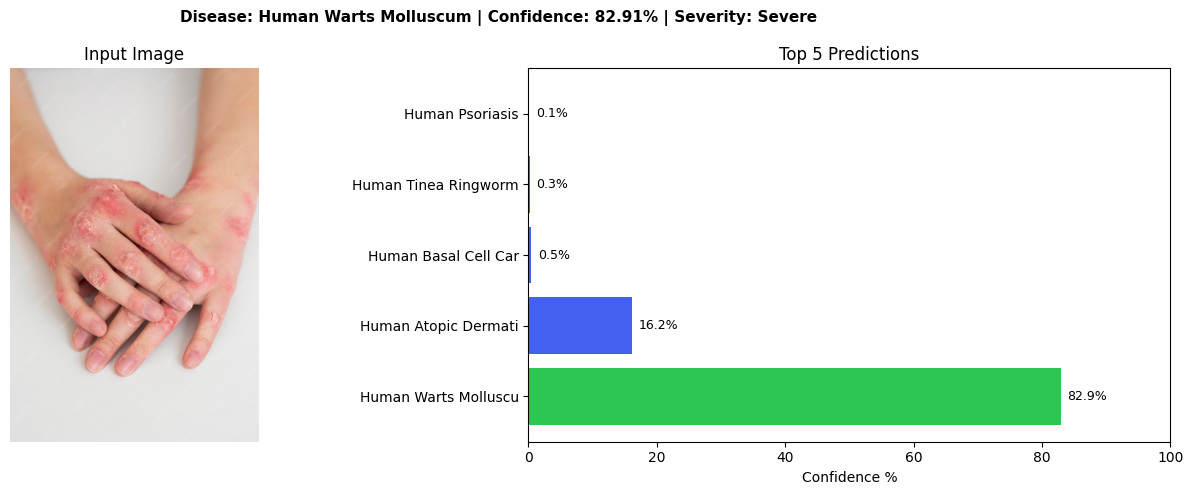

✅ Visualization saved!


In [9]:
# Cell 8 - Visualize prediction results
def visualize_prediction(result):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Show image
    ax1.imshow(result['image'])
    ax1.set_title(f"Input Image", fontsize=12)
    ax1.axis('off')
    
    # Show confidence bar chart
    diseases = [d.replace('_', ' ').title()[:20] 
                for d, _ in result['top5']]
    probs    = [p for _, p in result['top5']]
    colors   = ['#2dc653' if i == 0 else '#4361ee' 
                for i in range(len(probs))]
    
    bars = ax2.barh(diseases, probs, color=colors)
    ax2.set_xlabel('Confidence %')
    ax2.set_title('Top 5 Predictions', fontsize=12)
    ax2.set_xlim(0, 100)
    
    # Add percentage labels
    for bar, prob in zip(bars, probs):
        ax2.text(bar.get_width() + 1, bar.get_y() + 
                 bar.get_height()/2,
                 f'{prob:.1f}%', va='center', fontsize=9)
    
    plt.suptitle(
        f"Disease: {result['disease']} | "
        f"Confidence: {result['confidence']}% | "
        f"Severity: {result['severity']}",
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(str(BASE_DIR / "reports" / "sample_prediction.png"))
    plt.show()
    print("✅ Visualization saved!")

visualize_prediction(result)

In [10]:
# Cell 9 - Save predict.py
predict_code = '''import torch
import torch.nn as nn
from torchvision import models, transforms
from pathlib import Path
from PIL import Image
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_DIR = Path(__file__).resolve().parent.parent

# Load class names
with open(BASE_DIR / "utils" / "dataset_info.json", "r") as f:
    dataset_info = json.load(f)

NUM_CLASSES = dataset_info["num_classes"]
CLASS_NAMES = dataset_info["class_names"]
SEVERITY_LABELS = ["Mild", "Moderate", "Severe"]

class SkinDiseaseModel(nn.Module):
    def __init__(self, num_classes):
        super(SkinDiseaseModel, self).__init__()
        self.backbone = models.efficientnet_b0(weights="DEFAULT")
        for param in list(self.backbone.parameters())[:-20]:
            param.requires_grad = False
        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()
        self.disease_head = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
        self.severity_head = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 3)
        )
    def forward(self, x):
        features     = self.backbone(x)
        disease_out  = self.disease_head(features)
        severity_out = self.severity_head(features)
        return disease_out, severity_out

def load_model():
    model = SkinDiseaseModel(num_classes=NUM_CLASSES).to(device)
    model.load_state_dict(
        torch.load(BASE_DIR / "checkpoints" / "best_model.pth",
                   map_location=device)
    )
    model.eval()
    return model

def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    image = Image.open(image_path).convert("RGB")
    return image, transform(image).unsqueeze(0)

def get_disease_key(disease_name):
    return disease_name.replace("human_", "")\
                       .replace("dog_", "")\
                       .replace("cat_", "")

def adjust_severity(severity_idx, patient_data):
    age       = patient_data.get("age", 25)
    duration  = patient_data.get("duration", "Less than 1 week")
    spreading = patient_data.get("spreading", False)
    itchy     = patient_data.get("itchy", False)
    species   = patient_data.get("species", "Human")
    if species == "Human":
        if age > 60 or age < 5:
            severity_idx = min(severity_idx + 1, 2)
    if "More than 1 month" in duration:
        severity_idx = min(severity_idx + 1, 2)
    elif "2-4 weeks" in duration:
        severity_idx = min(severity_idx + 1, 2)
    if spreading:
        severity_idx = min(severity_idx + 1, 2)
    if itchy and severity_idx == 0:
        severity_idx = 1
    return severity_idx

def predict(image_path, patient_data, model):
    original_image, image_tensor = preprocess_image(image_path)
    image_tensor = image_tensor.to(device)
    with torch.no_grad():
        disease_out, severity_out = model(image_tensor)
    disease_probs = torch.softmax(disease_out, dim=1)
    disease_idx   = disease_probs.argmax().item()
    confidence    = float(disease_probs.max().item()) * 100
    top5_probs, top5_idx = torch.topk(disease_probs, 5)
    top5 = [
        (CLASS_NAMES[idx], float(prob) * 100)
        for idx, prob in zip(top5_idx[0], top5_probs[0])
    ]
    severity_idx = severity_out.argmax().item()
    severity_idx = adjust_severity(severity_idx, patient_data)
    severity     = SEVERITY_LABELS[severity_idx]
    disease_name = CLASS_NAMES[disease_idx]
    disease_key  = get_disease_key(disease_name)
    return {
        "disease":    disease_name.replace("_", " ").title(),
        "confidence": round(confidence, 2),
        "severity":   severity,
        "top5":       top5,
        "image":      original_image,
        "disease_key": disease_key
    }
'''

save_path = BASE_DIR / "model" / "predict.py"
with open(save_path, "w") as f:
    f.write(predict_code)

print(f"✅ predict.py saved to {save_path}")
print("🎉 Prediction Notebook Complete!")

✅ predict.py saved to C:\Users\shruti\Desktop\project\Skin-Disease Predictor\model\predict.py
🎉 Prediction Notebook Complete!
